# Подготовка библиотек и пакетов

In [ ]:
!pip install cooltools

  Using cached cooltools-0.7.1.tar.gz (8.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached bioframe-0.8.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached cython-3.2.4-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.5 kB)
Using cached bioframe-0.8.0-py3-none-any.whl (153 kB)
Using cached cython-3.2.4-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.9 MB/s eta 0:00:00
  Created wheel for cooltools: filename=cooltools-0.7.1-cp311-cp311-linux_x86_64.whl size=233402 sha256=74131a541b27965c4d4e648c73183c8804839d57f973b4265c044a062bec665f
  Stored in directory: /root/.cache/pip/wheels/4f/0

In [ ]:
!pip install cooler

In [ ]:
# подключаю диск
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import cooler
import cooltools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import bioframe
from scipy.signal import find_peaks
from matplotlib.ticker import EngFormatter
import itertools
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Файлы с диска

In [ ]:
mcool1 = '/content/drive/MyDrive/4DNFI5WQDFVW.mcool'
mcool2 = '/content/drive/MyDrive/4DNFIV1TAIKG.mcool'

# a) получить информацию и атрибуты матрицы Hi-C с помощью cooler.info


In [ ]:
!cooler info /content/drive/MyDrive/4DNFI5WQDFVW.mcool::/resolutions/25000

{
    "bin-size": 25000,
    "bin-type": "fixed",
    "creation-date": "2025-09-16T11:54:35.216968",
    "format": "HDF5::Cooler",
    "format-url": "https://github.com/open2c/cooler",
    "format-version": 3,
    "generated-by": "cooler-0.9.3",
    "genome-assembly": "unknown",
    "nbins": 109032,
    "nchroms": 21,
    "nnz": 243605359,
    "storage-mode": "symmetric-upper",
    "sum": 551441943
}


In [ ]:
!cooler info /content/drive/MyDrive/4DNFIV1TAIKG.mcool::/resolutions/25000

{
    "bin-size": 25000,
    "bin-type": "fixed",
    "creation-date": "2025-11-12T19:24:22.479806",
    "format": "HDF5::Cooler",
    "format-url": "https://github.com/open2c/cooler",
    "format-version": 3,
    "generated-by": "cooler-0.9.3",
    "genome-assembly": "unknown",
    "nbins": 123541,
    "nchroms": 24,
    "nnz": 194734512,
    "storage-mode": "symmetric-upper",
    "sum": 769747784
}


# b) открыть объект cooler как сбалансированную матрицу для внутрихромосомных контактов

In [ ]:
clr1 = cooler.Cooler(f'{mcool1}::/resolutions/25000')
clr2 = cooler.Cooler(f'{mcool2}::/resolutions/25000')

print("Объект experiment1:", clr1)
print("Объект experiment2:", clr2)

Объект experiment1: <Cooler "4DNFI5WQDFVW.mcool::/resolutions/25000">
Объект experiment2: <Cooler "4DNFIV1TAIKG.mcool::/resolutions/25000">


In [ ]:
# названия хромосом
print("Хромосомы в experiment1:", clr1.chromnames)
print("Хромосомы в experiment2:", clr2.chromnames)

Хромосомы в experiment1: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chrX', 'chrY']
Хромосомы в experiment2: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']


In [ ]:
m1=clr1.matrix().fetch('chr19')
m2=clr2.matrix().fetch('chr19')

print(m1)
print(m2)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
[[       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 ...
 [       nan        nan        nan ... 0.51976249        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


In [ ]:
# маленький участок матрицы
m_small = clr1.matrix().fetch('chr19:50,000,000-51,000,000')
print("Матрица 1x1 Мб участка:")
print(m_small)

# проверка на NaN
print(f"NaN: {np.isnan(m_small).sum()}, Всего: {m_small.size}")

Матрица 1x1 Мб участка:
[[0.06809989 0.02654349 0.01357014 ... 0.0008341  0.00083004 0.00041236]
 [0.02654349 0.05124235 0.02812349 ... 0.         0.00023489 0.00035007]
 [0.01357014 0.02812349 0.06322811 ... 0.00038864 0.         0.        ]
 ...
 [0.0008341  0.         0.00038864 ... 0.07390976 0.02128357 0.01244736]
 [0.00083004 0.00023489 0.         ... 0.02128357 0.04289586 0.02637168]
 [0.00041236 0.00035007 0.         ... 0.01244736 0.02637168 0.05558133]]
NaN: 199, Всего: 10000


In [ ]:
# сбалансированные данные внутрихромосомных контактов (взяла хромосому 19)
cis_matrix_balanced1 = clr1.matrix(balance=True).fetch('chr19')
cis_matrix_balanced2 = clr2.matrix(balance=True).fetch('chr19')

print("cis_matrix_balanced1:", cis_matrix_balanced1)
print("cis_matrix_balanced2:", cis_matrix_balanced2)

cis_matrix_balanced1: [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
cis_matrix_balanced2: [[       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 ...
 [       nan        nan        nan ... 0.51976249        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


In [ ]:
region = 'chr19:50,000,000-51,000,000'
# сбалансированная матрица для маленького участка
cis_small1 = clr1.matrix(balance=True).fetch(region)
cis_small2 = clr2.matrix(balance=True).fetch(region)

print("Experiment 1")
print(f"Участок: {region}")
print("Первые 10x10 значений:")
print(cis_small1[:10, :10])
print(f"NaN: {np.isnan(cis_small1).sum()}, Всего: {cis_small1.size}")

print("\nExperiment 2")
print(f"Участок: {region}")
print("Первые 10x10 значений:")
print(cis_small2[:10, :10])
print(f"NaN: {np.isnan(cis_small2).sum()}, Всего: {cis_small2.size}")

Experiment 1
Участок: chr19:50,000,000-51,000,000
Первые 10x10 значений:
[[0.06809989 0.02654349 0.01357014 0.00772848 0.00595742 0.00490092
  0.00606475 0.00235257 0.0019433  0.00236785]
 [0.02654349 0.05124235 0.02812349 0.00857996 0.00578011 0.00754121
  0.00231692 0.0051928  0.00439942 0.00268027]
 [0.01357014 0.02812349 0.06322811 0.02769981 0.01691901 0.00770685
  0.00621672 0.00350766 0.00422546 0.00343238]
 [0.00772848 0.00857996 0.02769981 0.04538526 0.02638245 0.0099914
  0.00715538 0.00489818 0.00292216 0.00419962]
 [0.00595742 0.00578011 0.01691901 0.02638245 0.03927127 0.02738928
  0.01265356 0.00872609 0.00686482 0.00453079]
 [0.00490092 0.00754121 0.00770685 0.0099914  0.02738928 0.04534564
  0.02624073 0.01043138 0.00764384 0.00752625]
 [0.00606475 0.00231692 0.00621672 0.00715538 0.01265356 0.02624073
  0.04852039 0.03897545 0.01169481 0.00800963]
 [0.00235257 0.0051928  0.00350766 0.00489818 0.00872609 0.01043138
  0.03897545 0.05634057 0.01992509 0.00953779]
 [0.0019

*При попытке вывести всю хромосому print показывает только углы матрицы, где значения очень близки к нулю (отсюда nan), так как вдали от диагонали контактов мало*

 # c) получить таблицу с координатами и контактами, они сбалансированные или нет?

In [ ]:
# только для 19 хромосомы, тк для обработки всех данных не хватет ОЗУ

# таблица бинов
bins = clr1.bins().fetch('chr19')

# пиксели
pix = clr1.pixels().fetch('chr19')

# объединение с координатами
pix_with_coords = pix.merge(
    bins.add_prefix('bin1_'), left_on='bin1_id', right_index=True
).merge(
    bins.add_prefix('bin2_'), left_on='bin2_id', right_index=True
)

print(pix_with_coords[['bin1_chrom', 'bin1_start', 'bin1_end',
                        'bin2_chrom', 'bin2_start', 'bin2_end', 'count']].head())

          bin1_chrom  bin1_start  bin1_end bin2_chrom  bin2_start  bin2_end  \
235816350      chr19     3075000   3100000      chr19     3075000   3100000   
235816351      chr19     3075000   3100000      chr19     3100000   3125000   
235816352      chr19     3075000   3100000      chr19     3125000   3150000   
235816353      chr19     3075000   3100000      chr19     3150000   3175000   
235816354      chr19     3075000   3100000      chr19     3175000   3200000   

           count  
235816350     51  
235816351      5  
235816352      4  
235816353      7  
235816354      1  


In [ ]:
# то же самое для другого файла
bins = clr2.bins().fetch('chr19')
pix = clr2.pixels().fetch('chr19')
pix_with_coords = pix.merge(
    bins.add_prefix('bin1_'), left_on='bin1_id', right_index=True
).merge(
    bins.add_prefix('bin2_'), left_on='bin2_id', right_index=True
)

print(pix_with_coords[['bin1_chrom', 'bin1_start', 'bin1_end',
                        'bin2_chrom', 'bin2_start', 'bin2_end', 'count']].head())

          bin1_chrom  bin1_start  bin1_end bin2_chrom  bin2_start  bin2_end  \
187467964      chr19       75000    100000      chr19       75000    100000   
187467965      chr19       75000    100000      chr19      100000    125000   
187467966      chr19       75000    100000      chr19     1850000   1875000   
187467967      chr19       75000    100000      chr19     4175000   4200000   
187467968      chr19       75000    100000      chr19    10250000  10275000   

           count  
187467964     26  
187467965      2  
187467966      1  
187467967      1  
187467968      1  


*Данные не сбалансированы.*

# d) получить таблицу в командной строке командой *cooler dump*

In [ ]:
# --join добавляет к выводу координаты бинов
# -range chr19 - сортировка по 19 хромосоме
!cooler dump --join --range chr19 {mcool1}::/resolutions/25000 | head -20

chr19	3075000	3100000	chr19	3075000	3100000	51
chr19	3075000	3100000	chr19	3100000	3125000	5
chr19	3075000	3100000	chr19	3125000	3150000	4
chr19	3075000	3100000	chr19	3150000	3175000	7
chr19	3075000	3100000	chr19	3175000	3200000	1
chr19	3075000	3100000	chr19	3200000	3225000	2
chr19	3075000	3100000	chr19	3225000	3250000	1
chr19	3075000	3100000	chr19	3300000	3325000	1
chr19	3075000	3100000	chr19	3325000	3350000	1
chr19	3075000	3100000	chr19	3450000	3475000	1
chr19	3075000	3100000	chr19	4175000	4200000	1
chr19	3075000	3100000	chr19	6300000	6325000	1
chr19	3075000	3100000	chr19	7200000	7225000	1
chr19	3075000	3100000	chr19	7575000	7600000	2
chr19	3075000	3100000	chr19	7650000	7675000	1
chr19	3075000	3100000	chr19	7700000	7725000	2
chr19	3075000	3100000	chr19	7725000	7750000	1
chr19	3075000	3100000	chr19	7750000	7775000	1
chr19	3075000	3100000	chr19	7775000	7800000	1
chr19	3075000	3100000	chr19	7850000	7875000	1


In [ ]:
!cooler dump --join --range chr19 {mcool2}::/resolutions/25000 | head -20

chr19	75000	100000	chr19	75000	100000	26
chr19	75000	100000	chr19	100000	125000	2
chr19	75000	100000	chr19	1850000	1875000	1
chr19	75000	100000	chr19	4175000	4200000	1
chr19	75000	100000	chr19	10250000	10275000	1
chr19	75000	100000	chr19	10425000	10450000	1
chr19	75000	100000	chr19	10700000	10725000	1
chr19	75000	100000	chr19	15375000	15400000	1
chr19	75000	100000	chr19	18025000	18050000	1
chr19	75000	100000	chr19	48125000	48150000	1
chr19	75000	100000	chr19	58325000	58350000	1
chr19	175000	200000	chr19	46800000	46825000	1
chr19	200000	225000	chr19	42175000	42200000	1
chr19	225000	250000	chr19	225000	250000	61
chr19	225000	250000	chr19	250000	275000	46
chr19	225000	250000	chr19	275000	300000	5
chr19	225000	250000	chr19	300000	325000	2
chr19	225000	250000	chr19	325000	350000	1
chr19	225000	250000	chr19	350000	375000	2
chr19	225000	250000	chr19	375000	400000	1


# e) посмотрите таблицу с бинами, какие столбцы там присутствуют?

In [ ]:
# таблица бинов для experiment1
bins1 = clr1.bins().fetch('chr19')
print("Experiment 1")
print("Столбцы:", bins1.columns.tolist())
print(bins1.head())

# для experiment2
bins2 = clr2.bins().fetch('chr19')
print("\nExperiment 2")
print("Столбцы:", bins2.columns.tolist())
print(bins2.head())

Experiment 1
Столбцы: ['chrom', 'start', 'end', 'KR', 'VC', 'VC_SQRT', 'weight']
       chrom   start     end  KR   VC  VC_SQRT  weight
96062  chr19       0   25000 NaN  0.0      0.0     NaN
96063  chr19   25000   50000 NaN  0.0      0.0     NaN
96064  chr19   50000   75000 NaN  0.0      0.0     NaN
96065  chr19   75000  100000 NaN  0.0      0.0     NaN
96066  chr19  100000  125000 NaN  0.0      0.0     NaN

Experiment 2
Столбцы: ['chrom', 'start', 'end', 'KR', 'VC', 'VC_SQRT', 'weight']
        chrom   start     end        KR        VC   VC_SQRT  weight
106184  chr19       0   25000       NaN  0.000000  0.000000     NaN
106185  chr19   25000   50000       NaN  0.000000  0.000000     NaN
106186  chr19   50000   75000       NaN  0.000000  0.000000     NaN
106187  chr19   75000  100000  0.058432  0.005693  0.068769     NaN
106188  chr19  100000  125000       NaN  0.000308  0.015989     NaN


# f) постройте кривые зависимости число контактов от расстояния для выбранной хромосомы (в логарифмических-координатах). Сравните их

/tmp/ipykernel_3393/2266917223.py:6: RuntimeWarning: Mean of empty slice
  z1[i] = np.nanmean(np.diagonal(m1, i)) # np.diagonal(m1, i) - извлекаем контакты на расстоянии i бинов
/tmp/ipykernel_3393/2266917223.py:12: RuntimeWarning: Mean of empty slice
  z2[i] = np.nanmean(np.diagonal(m2, i))
/tmp/ipykernel_3393/2266917223.py:17: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.arange(len(z2)) * resolution, np.log(z2), label='Experiment 2')


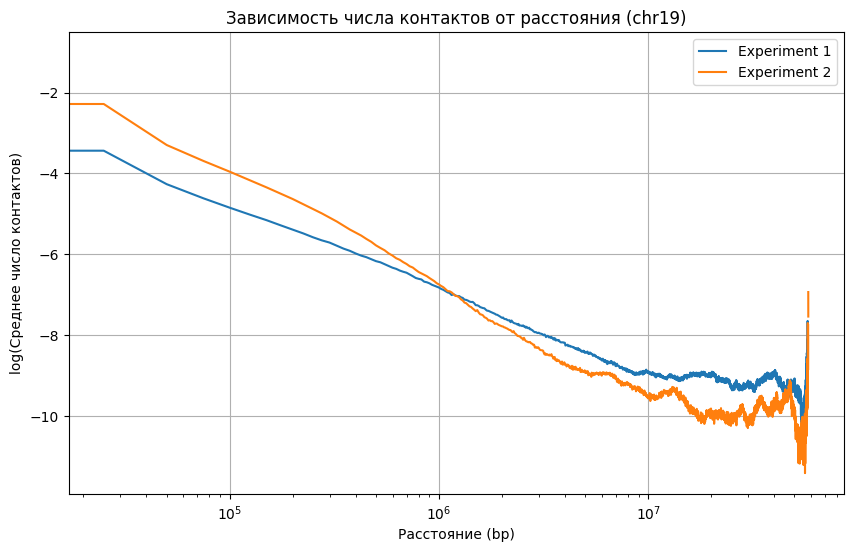

In [ ]:
resolution = 25000  # разрешение

# Для experiment1
z1 = np.zeros(len(m1)) # создание массива для средних значений на каждой диагонали
for i in range(len(m1)): # перебор расстояний
    z1[i] = np.nanmean(np.diagonal(m1, i)) # np.diagonal(m1, i) - извлекаем контакты на расстоянии i бинов
                                           # np.nanmean - усредняем, игнорируя nan

# Для experiment2
z2 = np.zeros(len(m2))
for i in range(len(m2)):
    z2[i] = np.nanmean(np.diagonal(m2, i))

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(z1)) * resolution, np.log(z1), label='Experiment 1')
plt.plot(np.arange(len(z2)) * resolution, np.log(z2), label='Experiment 2')
plt.xscale('log')
plt.xlabel('Расстояние (bp)')
plt.ylabel('log(Среднее число контактов)')
plt.title('Зависимость числа контактов от расстояния (chr19)')
plt.legend()
plt.grid(True)
plt.show()

*Оба эксперимента показывают ожидаемую закономерность: контакты уменьшаются с увеличением расстояния. Небольшой подъём на конце графиков связан с тем, что дальние диагонали меньше по длине, то есть небольшие изменения дают большую дисперсию.*

# g) для выбранного участка найдите insulation score и границы тадов для обоих файлов

In [ ]:
resolution = 25000

# выбранный участок
region = 'chr7:88,009,876-89,009,876'
chrom = 'chr7'
start = 88009876
end = 89009876
view_df = pd.DataFrame({
    'chrom': [chrom],
    'start': [start],
    'end': [end]
})

view_df = bioframe.make_viewframe(view_df)

# Размеры окон в бинах
windows = [3*resolution, 5*resolution, 10*resolution, 25*resolution]

# insulation score
insulation_table1 = cooltools.insulation(clr1, windows, view_df=view_df, verbose=True)
insulation_table2 = cooltools.insulation(clr2, windows, view_df=view_df, verbose=True)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr7
INFO:root:fallback to serial implementation.
INFO:root:Processing region chr7


In [ ]:
insulation_table1

,chrom,start,end,region,is_bad_bin,log2_insulation_score_75000,n_valid_pixels_75000,log2_insulation_score_125000,n_valid_pixels_125000,log2_insulation_score_250000,...,log2_insulation_score_625000,n_valid_pixels_625000,boundary_strength_75000,boundary_strength_125000,boundary_strength_625000,boundary_strength_250000,is_boundary_75000,is_boundary_125000,is_boundary_250000,is_boundary_625000
43351,chr7,88000000,88025000,chr7,False,0.538356,1.0,0.573874,3.0,0.562836,...,0.408193,23.0,NaN,NaN,NaN,NaN,False,False,False,False
43352,chr7,88025000,88050000,chr7,False,0.241323,3.0,0.342797,7.0,0.474529,...,0.350079,47.0,NaN,NaN,NaN,NaN,False,False,False,False
43353,chr7,88050000,88075000,chr7,False,-0.006570,6.0,0.173911,12.0,0.402223,...,0.312406,72.0,NaN,NaN,NaN,NaN,False,False,False,False
43354,chr7,88075000,88100000,chr7,False,-0.123143,6.0,0.037034,17.0,0.298834,...,0.254992,97.0,0.260205,NaN,NaN,NaN,True,False,False,False
43355,chr7,88100000,88125000,chr7,False,-0.113875,6.0,-0.092690,22.0,0.215589,...,0.203498,122.0,NaN,0.127774,NaN,NaN,False,True,False,False
43356,chr7,88125000,88150000,chr7,False,-0.034332,6.0,-0.067576,22.0,0.164410,...,0.163743,147.0,NaN,NaN,NaN,NaN,False,False,False,False
43357,chr7,88150000,88175000,chr7,False,0.000000,6.0,-0.046026,22.0,0.111501,...,0.118726,172.0,NaN,NaN,NaN,NaN,False,False,False,False
43358,chr7,88175000,88200000,chr7,False,0.013089,6.0,-0.069366,22.0,0.022224,...,0.062379,197.0,NaN,0.023340,NaN,NaN,False,False,False,False
43359,chr7,88200000,88225000,chr7,False,-0.004548,6.0,-0.037568,22.0,-0.020113,...,0.020321,222.0,0.017636,NaN,NaN,NaN,False,False,False,False
43360,chr7,88225000,88250000,chr7,False,0.035333,6.0,0.002329,22.0,-0.056221,...,-0.016792,247.0,NaN,NaN,NaN,0.010122,False,False,False,False


In [ ]:
print(insulation_table1.columns.tolist())

['chrom', 'start', 'end', 'region', 'is_bad_bin', 'log2_insulation_score_75000', 'n_valid_pixels_75000', 'log2_insulation_score_125000', 'n_valid_pixels_125000', 'log2_insulation_score_250000', 'n_valid_pixels_250000', 'log2_insulation_score_625000', 'n_valid_pixels_625000', 'boundary_strength_75000', 'boundary_strength_125000', 'boundary_strength_625000', 'boundary_strength_250000', 'is_boundary_75000', 'is_boundary_125000', 'is_boundary_250000', 'is_boundary_625000']


In [ ]:
# границы тадов

def find_boundaries(insulation_table, window_col, prominence=0.01): # prominence - параметр из find_peaks, который отсеивает слишком маленькие пики
    # find_peaks ищет локальные максимумы, а так как нам нужны минимумы - ставим минус
    # peaks -	массив индексов	(номера строк, где найдены пики)
    # props - словарь	(дополнительные параметры каждого пика)
    peaks, props = find_peaks(-insulation_table[window_col].values, prominence=prominence)

    # координаты границ
    boundaries = insulation_table.iloc[peaks]['start'].values

    # высота пика
    strengths = props['prominences']

    return boundaries, strengths

col = 'log2_insulation_score_75000'

bounds1, strengths1 = find_boundaries(insulation_table1, col)
bounds2, strengths2 = find_boundaries(insulation_table2, col)

print(f"Experiment 1: {len(bounds1)} границ ТАДов")
print(f"Experiment 2: {len(bounds2)} границ ТАДов")

Experiment 1: 7 границ ТАДов
Experiment 2: 6 границ ТАДов


# h) сравните результаты и постройте графики полученных кривых. Отобразите на них границы  ТАДов

In [ ]:
# функция для отображения Hi-C матрицы в виде треугольника (поворот на 45 градусов)
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    # вектор координат для каждого бина
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    n = matrix_c.shape[0] # размер матрицы
    t = np.array([[1, 0.5], [-1, 0.5]]) # матрица поворота на 45 градусов и сжатия
    # сетка координат для повернутого изображения
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    # преобразование в 2d массивы
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)

    # матрица
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

# форматирование подписей осей (преобразование больших чисел в удобный вид)
bp_formatter = EngFormatter('b')  # 'b' означает base pairs

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

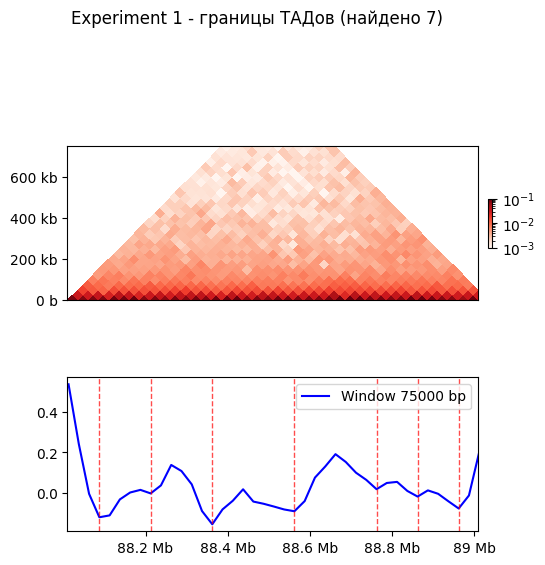

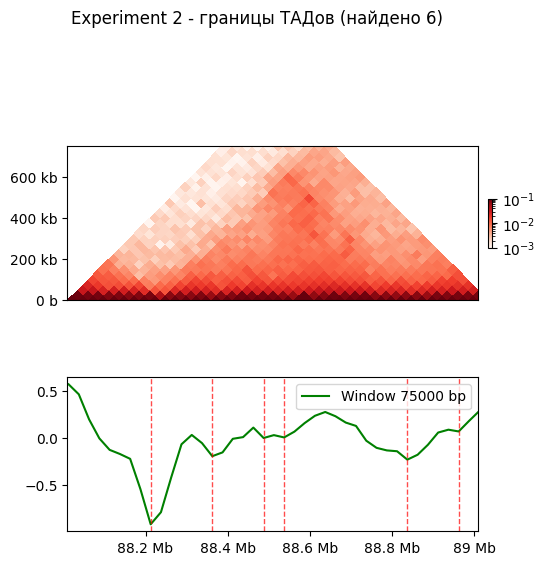

In [ ]:
plt.rcParams['font.size'] = 10 # глобальная настройка размера шрифта

# выбранный участок (chr7, 1 Мб)
start = 88_009_876
end = start + 1_000_000  # 1 Мб
region = ('chr7', start, end)

# логарифмическая шкала цветов (от 0.001 до 0.1)
norm = LogNorm(vmax=0.1, vmin=0.001)

# загрузка матрицы контактов для Experiment 1
data = clr1.matrix(balance=True).fetch(region)

# рисуем матрицу
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='Reds')
ax.set_aspect(0.5)
ax.set_ylim(0, 10 * windows[0])  # ограничение для высоты
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)  # скрыть ось X (будет на графике insulation)

# сolorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

# выбираем участок из insulation_table
insul_region = bioframe.select(insulation_table1, region)

# insulation score под матрицей
ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'],
            label=f'Window {windows[0]} bp', color='blue')

# добавление границ тадов (красные вертикальные линии)
for b in bounds1:
    if start <= b <= end:
        ins_ax.axvline(x=b, color='red', linestyle='--', alpha=0.7, linewidth=1)

ins_ax.legend(loc='upper right')
format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])
plt.suptitle(f'Experiment 1 - границы ТАДов (найдено {len(bounds1)})')
plt.show()


# все то же самое для другого файла

data = clr2.matrix(balance=True).fetch(region)

f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='Reds')
ax.set_aspect(0.5)
ax.set_ylim(0, 10 * windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table2, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'],
            label=f'Window {windows[0]} bp', color='green')

for b in bounds2:
    if start <= b <= end:
        ins_ax.axvline(x=b, color='red', linestyle='--', alpha=0.7, linewidth=1)

ins_ax.legend(loc='upper right')
format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])
plt.suptitle(f'Experiment 2 - границы ТАДов (найдено {len(bounds2)})')
plt.show()

Сравнение результатов:

* Совпадают 5 границ тадов: около 88.2 Mb, около 88.4 Mb, около 88.6 Mb, около 88.8 Mb, около 89 Mb
* Не совпадают 4 границ: около 88 Mb, между совпавшими границами около 88.4 Mb и около 88.6 Mb, между совпавшими границами около 88.6 Mb и около 88.8 Mb, между совпавшими границами около 88.8 Mb и около 89 Mb

Оба эксперимента выявляют сходные результаты, но с разной детализацией.Локализация дополнительных границ (несовпавшие границы) указывает на суб-тады

# i) cоздайте 2 bed файла с границами ТАДов.В поле score добавьте силу границы.

In [ ]:
# для Experiment 1
bed1 = pd.DataFrame({
    'chrom': ['chr7'] * len(bounds1), # хромосома (одна и та же для всех границ)
    'start': bounds1.astype(int), # координата начала границы
    'end': (bounds1 + 25000).astype(int), # координата конца
    'score': strengths1 # сила границы (значение prominence)
})

# для Experiment 2
bed2 = pd.DataFrame({
    'chrom': ['chr7'] * len(bounds2),
    'start': bounds2.astype(int),
    'end': (bounds2 + 25000).astype(int),
    'score': strengths2
})

# сохранение в файлы (tab-разделитель, без заголовка)
bed1.to_csv('boundaries_experiment1.bed', sep='\t', index=False, header=False)
bed2.to_csv('boundaries_experiment2.bed', sep='\t', index=False, header=False)

print("Файлы созданы:")
print("  boundaries_experiment1.bed")
print("  boundaries_experiment2.bed")

Файлы созданы:
  boundaries_experiment1.bed
  boundaries_experiment2.bed


# j) как меняется число ТАДов с изменением размера окна? Выберете как минимум 4-5 значений и постройте график.

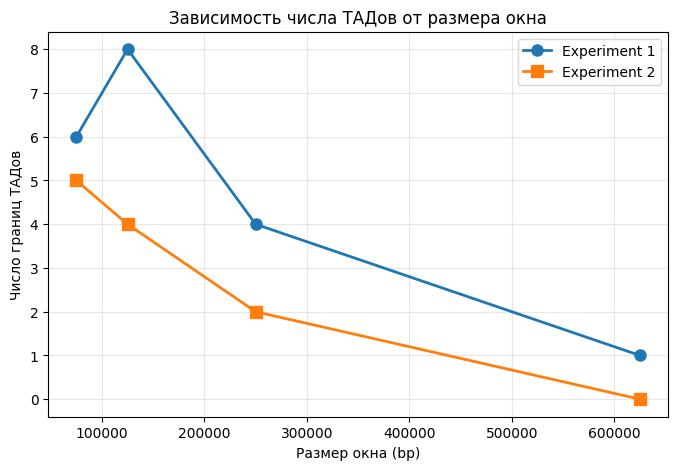

Размер окна (kb) Experiment 1 Experiment 2
----------------------------------------
75              6            5           
125             8            4           
250             4            2           
625             1            0           


In [ ]:
window_sizes = [75000, 125000, 250000, 625000]  # размеры окон

# количество границ для каждого окна
counts1 = []  # для Experiment 1
counts2 = []  # для Experiment 2

for w in window_sizes:
    col = f'boundary_strength_{w}'

    # Experiment 1
    values1 = insulation_table1[col].dropna().values # удаление nan
    counts1.append(len(values1))  # все границы

    # Experiment 2
    values2 = insulation_table2[col].dropna().values
    counts2.append(len(values2))

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(window_sizes, counts1, 'o-', label='Experiment 1', linewidth=2, markersize=8)
plt.plot(window_sizes, counts2, 's-', label='Experiment 2', linewidth=2, markersize=8)
plt.xlabel('Размер окна (bp)')
plt.ylabel('Число границ ТАДов')
plt.title('Зависимость числа ТАДов от размера окна')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод таблицы
print(f"{'Размер окна (kb)':<15} {'Experiment 1':<12} {'Experiment 2':<12}")
print("-" * 40)
for w, c1, c2 in zip(window_sizes, counts1, counts2):
    print(f"{w//1000:<15} {c1:<12} {c2:<12}")

*Общая закономерность: с увеличением размера окна число тадов уменьшается (за исключением аномалии при 125000 в Experiment 1), поскольку большое окно размывает мелкие детали и выявляет только крупные домены.*

# На 9-10
# Найдите ТАДы любым другим инструментом и сравните с предыдущим результатом


In [ ]:
import matplotlib
matplotlib.use('Agg')
!pip install chromosight

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 6.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=9f50b5e0a00e58a6c967cd7fd0dee8d036ad6ebb560f7801dfcdfa542c7b101e
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [ ]:
!chromosight --version

  - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  |                          @ @ @                           |
  |                , @ @ % , , @ , , , , % ,                 |
  |            , % , , # # , , @ , , , , , , % ,             |
  |          , , , , , % # % # @ @ % x , , , , , %           |
  |        % # , , , # @ # # , @ , , x % % , , , , @         |
  |      , , # # x @ , , @ # % @ , , , , , # x , , , %       |
  |    , , , # # % , , , % # % @ , , , , , , % % , , , ,     |
  |    % , , @ % % , , , , # @ @ , , , , , , , % % , , %     |
  |  , , , , @ # # , , , , # # @ , , , , , , , , % , , , ,   |
  |  @ , , @ , % # @ , , , # # @ , , # % , , , , , @ , , %   |
  |  , , , @ , , # # @ , , # # @ , % # % , , , , , % , , ,   |
  |  , , x % , , , # # # % # # @ # % , , % , , , , x % , ,   |
  |  , , % , , , , , @ # # # % @ , , , , @ , , , , , @ , , @ |
  |@ , , # , , , , , , % # # # @ , , , , # , , , , , # , , , |
  |@ @ @ @ @ @ @ @ @ @ @ # , # # @ , # @ @ @ @ @ @ @ @ 

In [ ]:
!chromosight --help

Pattern exploration and detection

Explore and detect patterns (loops, borders, centromeres, etc.) in Hi-C contact
maps with pattern matching.

Usage:
    chromosight detect  [--kernel-config=FILE] [--pattern=loops]
                        [--pearson=auto] [--win-size=auto] [--iterations=auto]
                        [--win-fmt={json,npy}] [--norm={auto,raw,force}]
                        [--subsample=no] [--inter] [--tsvd] [--smooth-trend]
                        [--n-mads=5] [--min-dist=0] [--max-dist=auto]
                        [--no-plotting] [--min-separation=auto] [--dump=DIR]
                        [--threads=1] [--perc-zero=auto]
                        [--perc-undetected=auto] <contact_map> <prefix>
    chromosight generate-config [--preset loops] [--click contact_map]
                        [--norm={auto,raw,norm}] [--win-size=auto] [--n-mads=5]
                        [--chroms=CHROMS] [--inter] [--threads=1] <prefix>
    chromosight quantify [--inter] [--pattern=loops] 

In [ ]:
mcool1 = '/content/drive/MyDrive/4DNFI5WQDFVW.mcool'
cool_uri = f"{mcool1}::/resolutions/25000"

!chromosight detect --pattern=borders {cool_uri} tads1_full

pearson set to 0.15 based on config file.
max_dist set to 0 based on config file.
min_dist set to 0 based on config file.
min_separation set to 5000 based on config file.
max_perc_undetected set to 75.0 based on config file.
max_perc_zero set to 10.0 based on config file.
Matrix already balanced, reusing weights
Found 96300 / 109032 detectable bins
Preprocessing sub-matrices...
 [====================] 100.0% chrY-chrY
Sub matrices extracted
Detecting patterns...
 [--------------------] 0.0% Kernel: 0, Iteration: 0
 [=======-------------] 33.3% Kernel: 1, Iteration: 0
 [=============-------] 66.7% Kernel: 2, Iteration: 0
 [====================] 100.0% Kernel: 2, Iteration: 0
Minimum pattern separation is : 1
13275 patterns detected
Saving patterns in tads1_full.tsv
Saving patterns in tads1_full.json
Saving pileup plots in tads1_full.pdf


In [ ]:
patterns = pd.read_csv('tads1_full.tsv', sep='\t')

print("Структура файла:")
print(patterns.columns.tolist())
print(f"\nВсего паттернов: {len(patterns)}")
print(patterns.head())

Структура файла:
['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'bin1', 'bin2', 'kernel_id', 'iteration', 'score', 'pvalue', 'qvalue']

Всего паттернов: 13275
  chrom1   start1     end1 chrom2   start2     end2  bin1  bin2  kernel_id  \
0   chr1  3725000  3750000   chr1  3725000  3750000   149   149          0   
1   chr1  3875000  3900000   chr1  3875000  3900000   155   155          0   
2   chr1  4400000  4425000   chr1  4400000  4425000   176   176          0   
3   chr1  4775000  4800000   chr1  4775000  4800000   191   191          0   
4   chr1  5200000  5225000   chr1  5200000  5225000   208   208          0   

   iteration     score        pvalue        qvalue  
0          0  0.457614  2.100000e-09  4.400000e-09  
1          0  0.322614  4.984600e-05  7.230180e-05  
2          0  0.634724  0.000000e+00  0.000000e+00  
3          0  0.779276  0.000000e+00  0.000000e+00  
4          0  0.594134  0.000000e+00  0.000000e+00  


In [ ]:
# регион
region_chrom = 'chr7'
region_start = 88009876
region_end = 89009876

# фильтрация
filtered = patterns[
    (patterns['chrom1'] == region_chrom) &
    (patterns['start1'] >= region_start) &
    (patterns['start1'] <= region_end)
]

print(f"Границ ТАДов в регионе {region_start}-{region_end}: {len(filtered)}")
print(filtered[['chrom1', 'start1', 'end1', 'score']].head())

Границ ТАДов в регионе 88009876-89009876: 3
      chrom1    start1      end1     score
1986    chr7  88375000  88400000  0.284260
6528    chr7  88400000  88425000  0.199008
10727   chr7  88600000  88625000  0.343077


In [ ]:
print(bounds1)

[88075000 88200000 88350000 88550000 88750000 88850000 88950000]


In [ ]:
# то же самое для другого файла
mcool2 = '/content/drive/MyDrive/4DNFIV1TAIKG.mcool'
cool_uri2 = f"{mcool2}::/resolutions/25000"

!chromosight detect --pattern=borders {cool_uri2} tads2_full

patterns2 = pd.read_csv('tads2_full.tsv', sep='\t')

filtered2 = patterns2[
    (patterns2['chrom1'] == region_chrom) &
    (patterns2['start1'] >= region_start) &
    (patterns2['start1'] <= region_end)
]

print(f"Границ ТАДов в регионе {region_start}-{region_end}: {len(filtered2)}")
print(filtered2[['chrom1', 'start1', 'end1', 'score']].head())

pearson set to 0.15 based on config file.
max_dist set to 0 based on config file.
min_dist set to 0 based on config file.
min_separation set to 5000 based on config file.
max_perc_undetected set to 75.0 based on config file.
max_perc_zero set to 10.0 based on config file.
Matrix already balanced, reusing weights
Found 108256 / 123541 detectable bins
Preprocessing sub-matrices...
 [====================] 100.0% chrY-chrY
Sub matrices extracted
Detecting patterns...
 [--------------------] 0.0% Kernel: 0, Iteration: 0
 [=======-------------] 33.3% Kernel: 1, Iteration: 0
 [=============-------] 66.7% Kernel: 2, Iteration: 0
 [====================] 100.0% Kernel: 2, Iteration: 0
Minimum pattern separation is : 1
15351 patterns detected
Saving patterns in tads2_full.tsv
Saving patterns in tads2_full.json
Saving pileup plots in tads2_full.pdf
Границ ТАДов в регионе 88009876-89009876: 6
      chrom1    start1      end1     score
2548    chr7  88225000  88250000  0.871037
2549    chr7  8882500

In [ ]:
print(bounds2)

[88200000 88350000 88475000 88525000 88825000 88950000]


*Сравнение результатов поиска ТАДов, полученных методами cooltools.insulation и chromosight, показало, что оба инструмента выявляют сходную структурную организацию хроматина в выбранном регионе. В Experiment 1 совпали 2 из 3 границ, найденных chromosight, с разницей в 25-50 kb от границ cooltools. В Experiment 2 наблюдается лучшее соответствие: 3 из 6 границ совпадают с точностью до 25 kb, включая полное совпадение границы на позиции 88825000. Различия в количестве границ обусловлены разными алгоритмами.*